In [1]:
import os
import pickle
import numpy as np
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import ustreasurycurve as ustcurve

from Library.Utility import UST_TENOR_MAP
from Library.OptionPricerBSM1973 import BlackScholesMertonPut
from Library.SkewCalibrationKimYi2025 import KimYiSkewCalibrationSystematic, KimYiSkewCalibrationIdiosyncratic, kimyi_vol_surface, _kimyi_imp_vol_call
from scipy.optimize import minimize
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

az.style.use("arviz-darkgrid")

DATA_PATH_STR = r"/Users/josephyi/Library/Mobile Documents/com~apple~CloudDocs/Data/Implied Volatility"
DATA_PATH_CALIB_RSLT_STR = os.path.join(os.path.join(os.getcwd(), os.pardir), r"Study/Estimated Parameters QLSQ")
UND_TICKERS_DICT = {'systematic': '^SPX', 'idiosyncratic': ['COIN']}
DIVIDEND_YIELDS = {'^SPX': 1.25, 'COIN': 0.}
EXPIRY_MAP = {0: 11, 1: 10, 2: 9, 3: 8, 4: 7}

In [2]:
valuation_date_array = pd.bdate_range('2025-03-18', '2025-04-17')
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.date_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_tenors = np.array([UST_TENOR_MAP[x] for x in rates_data_df.columns])
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-18,4.37,4.35,4.33,4.34,4.29,4.29,4.13,4.04,4.01,4.07,4.18,4.29,4.61,4.58
2025-03-19,4.37,4.34,4.32,4.33,4.30,4.29,4.10,3.99,3.95,4.03,4.14,4.25,4.58,4.56
2025-03-20,4.36,4.34,4.34,4.33,4.29,4.27,4.06,3.95,3.93,4.01,4.12,4.24,4.57,4.55
2025-03-21,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59
2025-03-22,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59


In [3]:
PATH_STR = os.path.join(DATA_PATH_STR, UND_TICKERS_DICT['systematic'].split("^")[-1])

mkt_vol_df1 = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

mkt_vol_df2 = []
for underlying_name in UND_TICKERS_DICT['idiosyncratic']:

    PATH_STR = os.path.join(DATA_PATH_STR, underlying_name)

    tmp_df = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

    mkt_vol_df2.append(tmp_df)

mkt_vol_df2 = pd.concat(mkt_vol_df2)
mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

mkt_vol_df.quote_date = pd.to_datetime(mkt_vol_df.quote_date)
mkt_vol_df.expiration = pd.to_datetime(mkt_vol_df.expiration)

mkt_vol_df['iEXPIRY'] = (mkt_vol_df.expiration - mkt_vol_df.quote_date).dt.days
mkt_vol_df['dEXPIRY'] = mkt_vol_df.iEXPIRY / 365

mkt_vol_df['dUND_PRICE'] = mkt_vol_df.active_underlying_price_1545
mkt_vol_df['dUND_STRIKE'] = mkt_vol_df.strike
mkt_vol_df['dMONEYNESS'] = mkt_vol_df.dUND_STRIKE / mkt_vol_df.dUND_PRICE * 100.
mkt_vol_df['dMKT_IMP_VOL'] = mkt_vol_df.implied_volatility_1545

mask = mkt_vol_df.option_type=='C'
mkt_vol_df['bIS_CALL_OPTION'] = False
mkt_vol_df.loc[mask, 'bIS_CALL_OPTION'] = True

mask  = (mkt_vol_df.trade_volume > 0) & (mkt_vol_df.iEXPIRY > 5) & (mkt_vol_df.dMKT_IMP_VOL > 0)
mkt_vol_df = mkt_vol_df.loc[mask]

mask = (mkt_vol_df.option_type=='P') & (mkt_vol_df.dMONEYNESS <= 100.) & (mkt_vol_df.dMONEYNESS >= 50.)
mkt_vol_df1 = mkt_vol_df.loc[mask]
mask = (mkt_vol_df.option_type=='C') & (mkt_vol_df.dMONEYNESS >= 100.) & (mkt_vol_df.dMONEYNESS <= 150.)
mkt_vol_df2 = mkt_vol_df.loc[mask]

mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

for t in mkt_vol_df.quote_date.unique():
    rate_fitter, _ = calibrate_nss_ols(rates_tenors, rates_data_df.xs(t).to_numpy() / 100)
    mask = (mkt_vol_df.quote_date==t)
    mkt_vol_df.loc[mask, 'dRISK_FREE_RATE'] = mkt_vol_df.loc[mask, 'dEXPIRY'].apply(rate_fitter)

mkt_vol_df['dDIVIDEND_YIELD'] = DIVIDEND_YIELDS[mkt_vol_df.underlying_symbol.iloc[0]] / 100.

vegas = []
for tup in mkt_vol_df.itertuples():
    vega = BlackScholesMertonPut(
        und_price=np.array(tup.dUND_PRICE),
        und_strike=np.array(tup.dUND_STRIKE),
        risk_free_rate=np.array(tup.dRISK_FREE_RATE),
        dividend_yield=np.array(tup.dDIVIDEND_YIELD),
        time_to_expiry=np.array(tup.dEXPIRY)
    ).vega(np.array(tup.dMKT_IMP_VOL)) / 100.
    vegas.append(vega[0, 0])

mkt_vol_df['dVEGA'] = vegas

In [4]:
initial_values_systematic = np.array([.2, .2, 5., 22., 7.])
initial_values_idiosyncratic = np.array([1., 2., 1., .5])

method = 'SLSQP'

bounds_systematic = {
    'dSIGMA': (1e-4, None),
    'dPPROB': (0., 1.),
    'dLAMB': (1e-4, None),
    'dETA1': (1.5, None),
    'dETA2': (0.5, None)
}

bounds_idiosyncratic = {
    'dKAPPAI': (1e-4, None),
    'dGAMMAI': (1e-1, None),
    'dBETAI': (1e-1, None),
    'dRHOIX': (-1., 1.)
}

calib_results = {}

In [5]:
calib_rslts_kimyi2025_file_name = "kimyi2025_vol_calibration.pkl"

try:
    # Open the file in binary read mode ('rb')
    file_path = os.path.join(DATA_PATH_CALIB_RSLT_STR, calib_rslts_kimyi2025_file_name)
    with open(file_path, 'rb') as file:
        # Load the pickled data
        calib_results = pickle.load(file)

    # Now, 'loaded_data' contains the Python object that was saved
    print("Data successfully loaded from pickle file:")
    print(file_path)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")

Data successfully loaded from pickle file:
/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Scripts/../Study/Estimated Parameters QLSQ/kimyi2025_vol_calibration.pkl


In [7]:
if not len(calib_results) > 0:

    systematic_name = UND_TICKERS_DICT['systematic']

    for valuation_date in valuation_date_array:

        if valuation_date in mkt_vol_df.quote_date.unique():

            valuation_date_str = valuation_date.strftime("%Y%m%d")

            key = f'{systematic_name}-{valuation_date_str}'

            display('--------')
            display(key)
            display('--------')

            if key in calib_results.keys():
                pass
            else:

                results_ = {}

                T = EXPIRY_MAP[valuation_date.weekday()]

                if (valuation_date >= pd.to_datetime('20250407')) and (valuation_date < pd.to_datetime('20250414')):
                    T = T - 1

                mask  = (mkt_vol_df.underlying_symbol==systematic_name)
                mask &= (mkt_vol_df.quote_date==valuation_date)
                mask &= (mkt_vol_df.iEXPIRY==T)
                mask &= (mkt_vol_df.dMONEYNESS >= 50.)
                mask &= (mkt_vol_df.dMONEYNESS <= 150.)

                tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')

                vol_fitter = KimYiSkewCalibrationSystematic(
                    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
                    und_price=tmp_df.dUND_PRICE.to_numpy(),
                    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
                    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
                    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
                    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
                    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
                    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
                )

                minimizer_results = minimize(
                    vol_fitter.target,
                    x0=initial_values_systematic,
                    method=method,
                    bounds=bounds_systematic.values(),
                    tol=1e-6,
                    options={'maxiter': 1e4}
                )

                display(minimizer_results)

                results_[valuation_date_str] = minimizer_results

                calib_results[key] = minimizer_results


    for underlying_name in UND_TICKERS_DICT['idiosyncratic']:
        for valuation_date in valuation_date_array:

            if valuation_date in mkt_vol_df.quote_date.unique():

                valuation_date_str = valuation_date.strftime("%Y%m%d")

                key = f'{underlying_name}-{valuation_date_str}'

                display('--------')
                display(key)
                display('--------')

                if key in calib_results.keys():
                    pass
                else:
                    results_ = {}

                    T = EXPIRY_MAP[valuation_date.weekday()]

                    if (valuation_date >= pd.to_datetime('20250407')) and (valuation_date < pd.to_datetime('20250414')):
                        T = T - 1

                    mask  = (mkt_vol_df.underlying_symbol==underlying_name)
                    mask &= (mkt_vol_df.quote_date==valuation_date)
                    mask &= (mkt_vol_df.iEXPIRY==T)
                    mask &= (mkt_vol_df.dMONEYNESS >= 50.)
                    mask &= (mkt_vol_df.dMONEYNESS <= 150.)

                    tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')

                    sigma, pprob, lamb, eta1, eta2 = calib_results[f"{systematic_name}-{valuation_date_str}"].x

                    vol_fitter = KimYiSkewCalibrationIdiosyncratic(
                        sigma=np.array(sigma),
                        pprob=np.array(pprob),
                        lamb=np.array(lamb),
                        eta1=np.array(eta1),
                        eta2=np.array(eta2),
                        mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
                        und_price=tmp_df.dUND_PRICE.to_numpy(),
                        und_strike=tmp_df.dUND_STRIKE.to_numpy(),
                        risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
                        dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
                        time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
                        is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
                        option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
                    )

                    minimizer_results = minimize(
                        vol_fitter.target,
                        x0=initial_values_idiosyncratic,
                        method=method,
                        bounds=bounds_idiosyncratic.values(),
                        tol=1e-6,
                        options={'maxiter': 1e4},
                        # constraints=({'type': 'ineq', 'fun': psi_constraint_aggregate})
                    )

                    display(minimizer_results)

                    results_[valuation_date_str] = minimizer_results

                    calib_results[key] = minimizer_results

    file_path = r"/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Study/Estimated Parameters QLSQ/kimyi2025_vol_calibration.pkl"

    try:
        with open(file_path, "wb") as file:
            pickle.dump(calib_results, file)
        print(f"Dictionary successfully saved to {file_path}")
    except Exception as e:
        print(f"An error occured: {e}")

In [8]:
valuation_date = '20250409'
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
if (pd.to_datetime(valuation_date) >= pd.to_datetime('20250407')) and (pd.to_datetime(valuation_date) < pd.to_datetime('20250414')):
    T = T - 1
mask  = (mkt_vol_df.underlying_symbol==UND_TICKERS_DICT['systematic'])
mask &= (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]

In [9]:
vol_fitter = KimYiSkewCalibrationSystematic(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL'] = vol_fitter.model_vol(x=calib_results[f"{UND_TICKERS_DICT['systematic']}-{valuation_date}"].x) * 100.

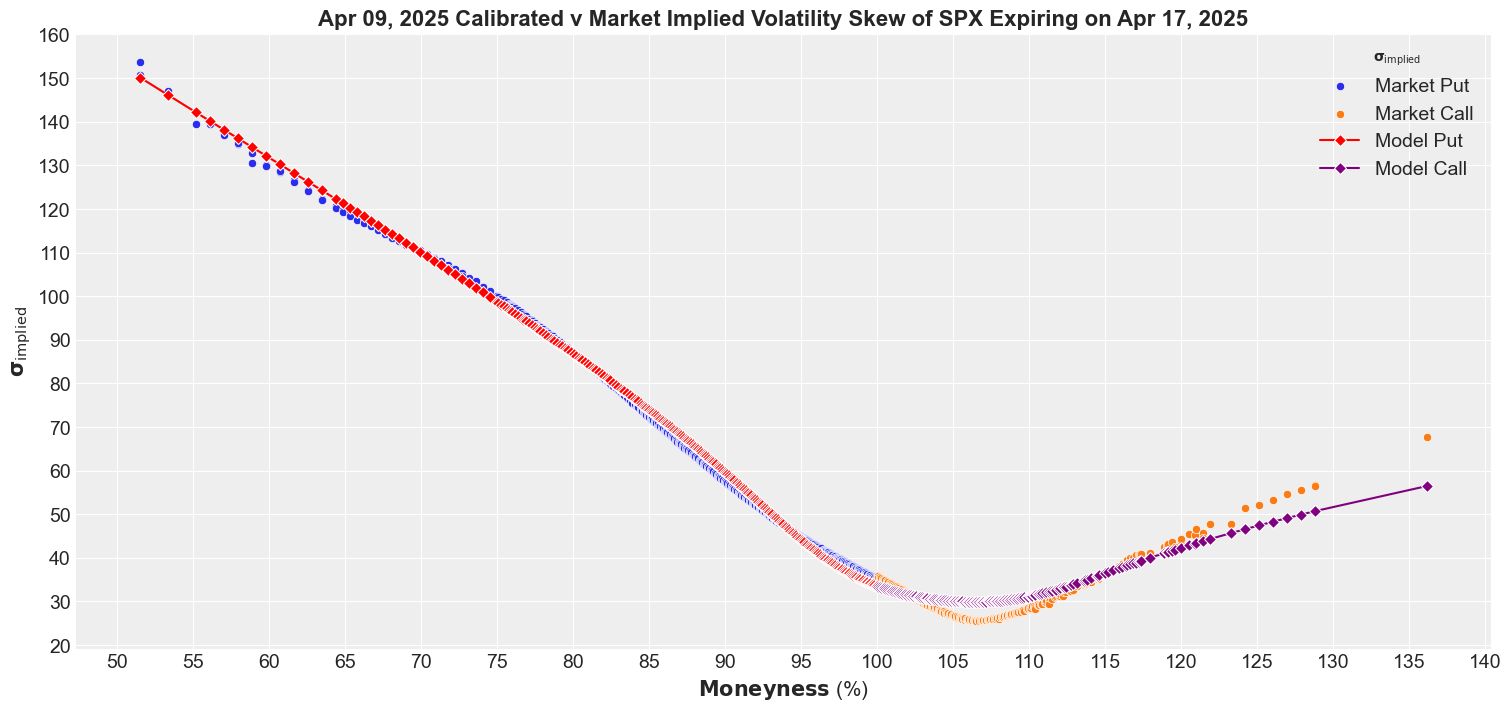

In [10]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Put',  ax=ax)
sns.scatterplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Call', ax=ax)
sns.lineplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Put',  ax=ax, color='r', marker='D')
sns.lineplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Call', ax=ax, color='purple', marker='D')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {UND_TICKERS_DICT["systematic"].split("^")[-1]} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
# plt.savefig(f"SPX_VOL_SKEW_{valuation_date_str}.pdf", dpi=300)
plt.show();

In [11]:
# valuation_date = '20250403'
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
if (pd.to_datetime(valuation_date) >= pd.to_datetime('20250407')) and (pd.to_datetime(valuation_date) < pd.to_datetime('20250414')):
    T = T - 1
mask  = (mkt_vol_df.underlying_symbol==UND_TICKERS_DICT['idiosyncratic'][0])
mask &= (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]

In [12]:
sigma, pprob, lamb, eta1, eta2 = calib_results[f"{UND_TICKERS_DICT['systematic']}-{valuation_date}"].x

vol_fitter = KimYiSkewCalibrationIdiosyncratic(
    sigma=np.array(sigma),
    pprob=np.array(pprob),
    lamb=np.array(lamb),
    eta1=np.array(eta1),
    eta2=np.array(eta2),
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL'] = vol_fitter.model_vol(x=calib_results[f"{UND_TICKERS_DICT['idiosyncratic'][0]}-{valuation_date}"].x) * 100.

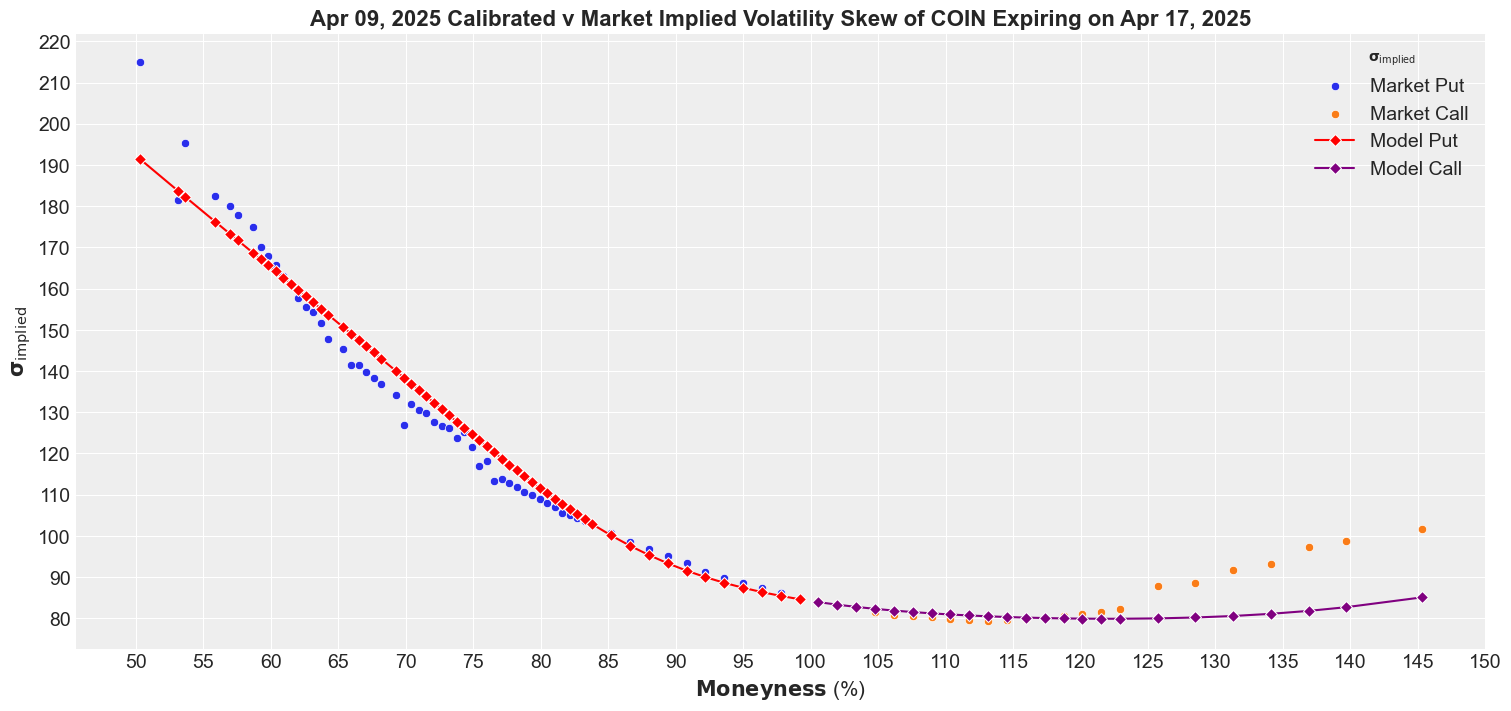

In [13]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Put',  ax=ax)
sns.scatterplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Call', ax=ax)
sns.lineplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Put',  ax=ax, color='r', marker='D')
sns.lineplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Call', ax=ax, color='purple', marker='D')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {UND_TICKERS_DICT["idiosyncratic"][0]} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
# plt.savefig(f"SPX_VOL_SKEW_{valuation_date_str}.pdf", dpi=300)
plt.show();

In [20]:
underlying_name = UND_TICKERS_DICT['idiosyncratic'][0]
expiry_in_days = np.array([1, 7, 14, 30, 60, 90, 180, 365])
und_strikes = np.linspace(50, 150, 101).reshape((-1, 1))
und_spot = np.array(100.)

vol_surface_rslts = {}
for valuation_date in [x.strftime("%Y%m%d") for x in valuation_date_array]:

    sigma, pprob, lamb, eta1, eta2 = calib_results[f"{UND_TICKERS_DICT['systematic']}-{valuation_date}"].x
    kappai, gammai, betai, rhoix = calib_results[f"{underlying_name}-{valuation_date}"].x
    rates = rates_data_df.xs(valuation_date).to_numpy().squeeze() * .01
    curve_fit, _ = calibrate_nss_ols(rates_tenors, rates)

    skew = []

    for expiry in expiry_in_days:

        expiry_in_years = expiry / 365

        vol_surface = kimyi_vol_surface(
            kappai=kappai,
            gammai=gammai,
            betai=betai,
            rhoix=rhoix,
            sigma=sigma,
            pprob=pprob,
            lamb=lamb,
            eta1=eta1,
            eta2=eta2,
            und_price=und_spot,
            und_strike=und_strikes,
            risk_free_rate=np.array(curve_fit(expiry_in_years)),
            dividend_yield=np.array(DIVIDEND_YIELDS[underlying_name]),
            time_to_expiry=expiry_in_years
        )

        skew.append(vol_surface.reshape((-1, )))

    vol_surface_rslts[f"{underlying_name}-{valuation_date}"] = {'iEXPIRY': expiry_in_days, 'dMONEYNESS': (und_strikes / und_spot).reshape((-1,)), 'dVOL': np.array(skew)}

file_path = r"/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Study/Vol Surface From Model/kimyi2025_vol_surface.pkl"

try:
    with open(file_path, "wb") as file:
        pickle.dump(vol_surface_rslts, file)
    print(f"Dictionary successfully saved to {file_path}")
except Exception as e:
    print(f"An error occured: {e}")

/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Library/SkewCalibrationKimYi2025.py:343: RuntimeWarning: some derivatives were zero
  mod_iv_call = newton(


Dictionary successfully saved to /Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/Study/Vol Surface From Model/kimyi2025_vol_surface.pkl


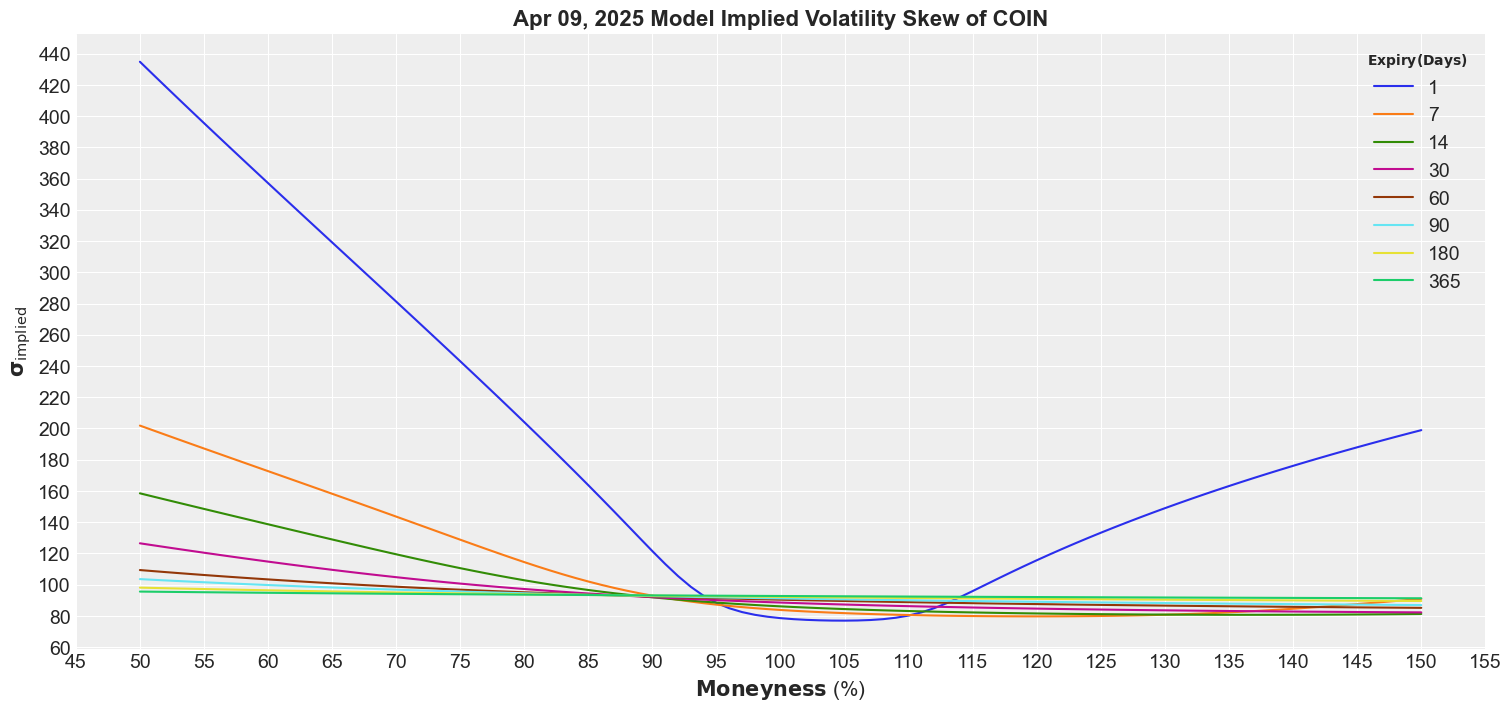

In [19]:
valuation_date = '20250409'
underlying_name = UND_TICKERS_DICT['idiosyncratic'][0]
tmp_dict = vol_surface_rslts[f"{underlying_name}-{valuation_date}"]
iEXPIRY = tmp_dict['iEXPIRY']
dMONEYNESS = tmp_dict['dMONEYNESS']
dVOL = tmp_dict['dVOL']

fig, ax = plt.subplots(figsize=(15, 7))

for i, d in enumerate(iEXPIRY):
    sns.lineplot(x=dMONEYNESS.reshape((-1,)) * 100., y=dVOL[i], label=f"{d}")

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf Expiry (Days)$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Model Implied Volatility Skew of {underlying_name}', weight='bold'
)
# plt.savefig(f"SPX_VOL_SKEW_{valuation_date_str}.pdf", dpi=300)
plt.show();